## Table of Contents

1. [Clustering](#Clustering)
    1. [Introduction](#theory)
    2. [K-Means Clustering](#kmeans)
    3. [DBSCAN](#dbscan)
    4. [Agglomerative Clustering](#agglom)
4. [Practice](#Practice)
    1. [Data Preparation & Visualization](#data-prep)
    2. [KMeans](#kmeansp)
    3. [Agglomerative Clustering](#agglomp)
    4. [DBSCAN](#dbscanp)

# Clustering<a id="Clustering">

Clustering is an unsupervised machine learning technique used to uncover natural groupings or patterns within data, without relying on predefined labels. By grouping similar data points together, clustering reveals hidden structures in datasets, making it a valuable tool for exploratory data analysis and a wide range of applications.

### Key Concepts and Definitions
* Clustering: The process of dividing a dataset into groups, or "clusters," where each cluster contains data points that are more similar to each other than to points in other clusters.

* Similarity: In clustering, similarity between data points is often defined by a distance metric (such as Euclidean distance) that quantifies how close or far apart data points are. The choice of similarity measure significantly impacts the clustering outcome.

### Applications of Clustering

Clustering has broad applications across various fields. Here are a few key examples:

1. Customer Segmentation: Grouping customers based on behavior or purchase history to identify distinct segments, tailor marketing strategies, and enhance personalization.

2. Document Organization: Clustering can be used to categorize large collections of documents, emails, or search results, making it easier to manage and retrieve similar items.

3. Image Segmentation: In computer vision, clustering can partition an image into regions based on similar features, which is useful for tasks like object detection or identifying areas with common characteristics.

### Types of Clustering Algorithms
Different clustering algorithms group data in unique ways, suited to different types of datasets and desired cluster shapes. Common types include:

- K-Means Clustering: Partitions data into a predefined number of clusters by minimizing variance within each cluster. It’s computationally efficient and effective for spherical clusters but struggles with more complex shapes.

- DBSCAN (Density-Based Spatial Clustering of Applications with Noise): Groups data based on density, making it ideal for identifying clusters of arbitrary shapes and distinguishing noise or outliers. It’s especially useful when clusters have irregular boundaries.

- Hierarchical Clustering (e.g., Agglomerative Clustering): Builds clusters in a hierarchical or nested structure, allowing clusters to be viewed at various levels of granularity. It’s well-suited for smaller datasets or situations where hierarchical relationships are important.

### K-Means Clustering <a id="kmeans">

K-Means is a popular distance-based clustering algorithm that groups similar data points into a predefined number of clusters, *K*. The objective of K-Means is to partition the data in a way that minimizes the variance within each cluster, resulting in groups where points are more similar to each other than to points in other clusters. This algorithm is particularly well-suited for spherical or well-separated clusters and is widely used due to its simplicity and efficiency.

### Key Steps in the K-Means Algorithm

1. **Select the Number of Clusters**: Determine the desired number of clusters, *K*, in advance. This is a crucial parameter that directly affects the final clustering results. Choosing an appropriate *K* often requires domain knowledge or trial and error, sometimes aided by methods like the "elbow method."

2. **Initialize Cluster Centers**: Randomly select *K* points in the dataset as the initial cluster centers (also known as "centroids"). These starting points serve as rough estimates of where each cluster might be located.

3. **Iterate**: Repeat the following two steps until convergence:
   - Assign Points to Clusters: For each data point, calculate its distance to each cluster center and assign it to the nearest one. This step forms the clusters based on proximity to the current centroids.
   - Update Cluster Centers: Recalculate the center of each cluster by taking the mean of all data points assigned to that cluster. This updated mean becomes the new centroid for the cluster.

4. **Convergence**: The algorithm continues to iterate between assignment and update steps until there are no changes in cluster assignments, or until the change in cluster centers falls below a pre-defined threshold. At this point, the algorithm is considered to have converged, meaning it has reached a stable configuration.

### Limitations of K-Means

- Predefined Number of Clusters: K-Means requires specifying *K* in advance, which is not always intuitive or easy to determine. Incorrectly choosing *K* can lead to poor clustering results.
- Assumption of Spherical Clusters: K-Means works best with clusters that are roughly spherical or evenly shaped. It struggles with clusters of varying densities or non-spherical shapes.
- Sensitivity to Initialization: The algorithm’s outcome can vary depending on the initial choice of centroids, potentially leading to different clusters each time it’s run. This issue is often mitigated by using multiple runs or improved initialization techniques like **K-Means++**.

### Choosing $K$ Using the Elbow Method

The Elbow Method is a popular technique for determining the optimal number of clusters, $K$, in K-Means clustering. It involves running the K-Means algorithm on the dataset for different values of $K$ and evaluating each result by measuring the "compactness" of the clusters, or how tightly grouped the data points are within each cluster.

#### Steps in the Elbow Method

1. **Apply K-Means for Different Values of $K$**: Run the K-Means algorithm multiple times, each time with a different number of clusters ($K = 1, 2, 3, \dots$). For each value of $K$, the algorithm partitions the data and computes the clusters' centroids.

2. **Calculate the Within-Cluster Sum of Squares (WCSS)**: For each value of $K$, calculate the total Within-Cluster Sum of Squares (WCSS), which measures the variance within each cluster. WCSS is calculated as:
   
   $\text{WCSS} = \sum_{j=1}^{K} \sum_{i \in C_j} \text{distance}(x_i, \mu_j)^2$
   
   where:
   - $K$ = number of clusters,
   - $C_j$ = points in cluster $j$,
   - $\mu_j$ = centroid (mean) of cluster $j$.

   A lower WCSS indicates that points are closer to their cluster centroids, suggesting more cohesive clusters.

3. **Plot $K$ vs. WCSS**: Create a plot of the number of clusters $K$ on the x-axis and the corresponding WCSS on the y-axis. As $K$ increases, WCSS generally decreases because more clusters lead to smaller, tighter groupings.

4. **Identify the "Elbow" Point**: The "elbow" point on the graph is where the rate of decrease in WCSS sharply slows. Before the elbow, adding more clusters significantly reduces WCSS, indicating improved clustering. After the elbow, the reduction in WCSS becomes more gradual, meaning additional clusters provide diminishing returns in terms of compactness.

   The value of $K$ at the elbow point is often considered the optimal number of clusters, as it strikes a balance between minimizing variance within clusters and keeping the model simple (avoiding overfitting).

#### Why the Elbow Method Works

The elbow point represents a trade-off: adding more clusters reduces variance within each cluster, but at some point, the improvement becomes negligible. Choosing $K$ at the elbow helps avoid overly complex models while ensuring the clusters are well-defined.

<img src="../images/elbow.png" style="float: left; margin-right: 10px;" />


In the elbow plot the image, the WCSS decreases steeply until $K = 4$, after which the reduction becomes more gradual. Thus, $K = 4$ would be a suitable choice for the number of clusters, as it is the point where adding more clusters yields diminishing returns.

### Choosing $K$ Using the Silhouette Method

The Silhouette Method is a technique used to determine the optimal number of clusters, $K$, by measuring how well each data point fits within its assigned cluster compared to other clusters. This method provides a metric called the **Silhouette Coefficient**, which reflects both the cohesion within clusters and the separation between clusters.

#### Understanding the Silhouette Coefficient

For each data point $i$:
- $a(i)$: **Intra-Cluster Distance** — the average distance between $i$ and all other points within the same cluster.
- $b(i)$: **Nearest-Cluster Distance** — the average distance between $i$ and all points in the nearest neighboring cluster (i.e., the closest cluster that $i$ is not a part of).

The Silhouette Coefficient $s(i)$ for each point $i$ is calculated as:
$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$
The coefficient $s(i)$ ranges from -1 to 1:
- A value close to 1 indicates that $i$ is well-matched to its cluster and poorly matched to other clusters.
- A value near 0 suggests that $i$ is on or near a cluster boundary.
- Negative values imply that $i$ may have been assigned to the wrong cluster.

The average Silhouette Coefficient for all points within a cluster, and then across all clusters, provides an overall measure of how appropriate the clustering is for a given $K$.

#### Steps in the Silhouette Method

1. **Apply K-Means for Different Values of $K$**: Run the K-Means algorithm for a range of cluster counts ($K = 2, 3, \dots, 10$) to explore different possible configurations.

2. **Calculate the Silhouette Coefficient for Each Point**: For each value of $K$, compute the Silhouette Coefficient $s(i)$ for every data point, quantifying how well each point fits within its assigned cluster.

3. **Compute the Average Silhouette Coefficient for Each $K$**: Calculate the mean Silhouette Coefficient across all data points for each $K$. This average represents how well-defined the clusters are at each value of $K$.

4. **Identify the Optimal $K$**: Plot the average Silhouette Coefficient against different values of $K$. The optimal number of clusters is the $K$ that maximizes the average Silhouette Coefficient, indicating the best balance of cohesion and separation. A high average Silhouette Coefficient suggests that the clusters are compact and well-separated.

<img src="../images/silh.png" style="float: left; margin-right: 10px; width: 600px" />


In the example above, the Silhouette Coefficient peaks at $K = 5$. This suggests that $K = 5$ provides the best clustering configuration, as it maximizes the separation between clusters while maintaining cohesion within clusters.

### DBSCAN (Density-Based Spatial Clustering of Applications with Noise)<a id="dbscan">

DBSCAN is a density-based clustering algorithm designed to identify clusters of various shapes and sizes, as well as to detect outliers. Unlike K-Means, DBSCAN doesn’t require specifying the number of clusters in advance, making it especially useful for discovering clusters with irregular boundaries or clusters where density varies.

#### Key Concepts in DBSCAN

- **Core Point**: A point is considered a core point if it has at least a minimum number of neighboring points (defined by the parameter `minPts`) within a specified distance (defined by the parameter `ε` or "eps").
- **Border Point**: A border point has fewer than `minPts` neighbors within `ε` but lies within the `ε` radius of a core point, making it part of a cluster.
- **Noise Point**: A noise point (or outlier) is any point that isn’t a core point and isn’t within the `ε` distance of any core point. These points do not belong to any cluster.

#### Steps in the DBSCAN Algorithm

1. **Initialize**: For each data point, determine if it qualifies as a core point by counting its neighboring points within the distance `ε`.

2. **Expand Clusters**:
   - For each core point, start a new cluster if it hasn't been assigned to one yet.
   - Add all points within `ε` distance that are density-reachable from this core point, expanding the cluster.
   - For each point added to the cluster, check if it is also a core point. If it is, continue expanding by adding its density-reachable points.
   - Repeat this expansion process until no more points can be added to the cluster.

3. **Identify Noise**: Points that don’t fall within any cluster (i.e., points that aren’t core or border points) are marked as noise or outliers.

#### Parameters in DBSCAN

- **`ε` (eps)**: Defines the radius of neighborhood around a point. This distance threshold is crucial for determining whether points are close enough to form a cluster.
- **`minPts`**: The minimum number of points required within the `ε` radius for a point to qualify as a core point. Higher values of `minPts` can lead to fewer, more compact clusters, while lower values can increase the number of clusters.

#### Advantages of DBSCAN

- Detection of Arbitrarily Shaped Clusters: DBSCAN can find clusters with various shapes (e.g., elongated, irregular) because it groups points based on density rather than distance to a center.
- Automatic Outlier Detection: DBSCAN naturally identifies outliers as points that don’t belong to any cluster. Noise points are effectively isolated and excluded from clusters, making the algorithm useful for datasets with noise.

#### Limitations of DBSCAN

- Difficulty with Varying Densities: DBSCAN struggles when clusters have widely varying densities, as a single `ε` value may not be suitable for all clusters.
- Parameter Sensitivity: The results of DBSCAN are sensitive to the choice of `ε` and `minPts`. Choosing optimal values often requires domain knowledge or experimentation.                                                                                                         

### Agglomerative Clustering<a id="agglom">

Agglomerative Clustering is a type of hierarchical clustering that builds a hierarchy of clusters by successively merging pairs of clusters. This approach is also known as a "bottom-up" method because it starts with each data point as its own cluster and then gradually merges clusters based on their similarity. The process continues until all points are combined into a single cluster or until a specified number of clusters is reached.

#### Steps in the Agglomerative Clustering Algorithm

1. **Initialize**: Start by treating each data point as an individual cluster, resulting in $N$initial clusters (where $N$is the number of data points).

2. **Expand Clusters**:
   - **Identify the Closest Clusters**: Using a selected distance metric (such as single linkage, complete linkage, or average linkage), find the two clusters that are closest to each other.
   - **Merge Clusters**: Combine these two closest clusters into a single new cluster.
   - **Update Distances**: After merging, recalculate the distances between the new cluster and all other clusters.
   - Repeat this process of finding, merging, and updating distances until the desired number of clusters is achieved or until all points are merged into one large cluster.

3. **Hierarchy of Clusters**: As the algorithm proceeds, it creates a nested sequence of clusters, which can be visualized as a tree-like structure called a **dendrogram**. By cutting the dendrogram at different levels, different clustering solutions can be obtained, offering flexibility in the choice of clusters.

#### Linkage Criteria

The choice of linkage criterion determines how the distance between clusters is calculated and affects the shape and characteristics of the final clusters. Common linkage criteria include:

- Single Linkage: Measures the minimum distance between any two points from different clusters. This method tends to produce elongated, chain-like clusters. 

- Complete Linkage: Measures the maximum distance between any two points in different clusters. This method is less prone to creating elongated shapes. Sensitive to outliers.

- Average Linkage: Calculates the average distance between all pairs of points across clusters. This criterion often strikes a balance between single and complete linkage, creating clusters of moderate compactness.

- Ward’s Linkage: Minimizes the variance within each cluster when merging clusters, often resulting in clusters that are more spherical and evenly sized. Ward’s linkage is particularly effective when clusters are expected to be relatively similar in size.

#### Advantages of Agglomerative Clustering

- Flexibility with Cluster Shapes and Sizes: Different linkage criteria allow the algorithm to adapt to various cluster shapes and densities, making it suitable for a wide range of data structures.
- Hierarchy of Clusters: The dendrogram produced by agglomerative clustering provides a visual representation of the hierarchy, making it easy to explore clustering at different levels of granularity.

#### Limitations of Agglomerative Clustering

- Computational Complexity: Agglomerative clustering can be computationally intensive, especially for large datasets, because it requires recalculating distances after each merge.
- Sensitivity to Noisy Data and Outliers: Agglomerative clustering may be affected by outliers, which can lead to misleading clusters if not handled carefully.

### Comparison

| Feature              | K-Means                  | DBSCAN                                 | Agglomerative Clustering                   |
|----------------------|--------------------------|----------------------------------------|--------------------------------------------|
| **Type**             | Centroid-based clustering | Density-based clustering               | Hierarchical clustering                    |
| **Cluster Shape**    | Assumes spherical clusters | Can find arbitrarily shaped clusters | Depends on the distance metric and linkage criteria |
| **Number of Clusters** | Must be specified in advance | Does not require specifying the number of clusters | Does not require specifying the number of clusters |
| **Outlier Handling** | Sensitive to outliers     | Effectively identifies and excludes outliers | Can be sensitive to noise, depending on linkage criteria |
| **Parameter Sensitivity** | Sensitive to the choice of K (number of clusters) | Sensitive to parameters like `eps` (neighborhood radius) and `minPts` (minimum points in a cluster) | Sensitive to the choice of distance metric and linkage method |


## Practice<a id="practice">

We’ll be using the **Mall Customer Segmentation Dataset**, which can be downloaded from [this link](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python).

This dataset contains information on 200 customers, including the following attributes:
- **Gender**: The customer’s gender, labeled as Male or Female.
- **Age**: The age of the customer in years.
- **Annual Income**: The yearly income of the customer in thousands of dollars.
- **Spending Score**: A score from 1 to 100 indicating the customer’s spending behavior and loyalty, with higher values suggesting higher spending.

Our objective is to cluster the customers into distinct groups where each group contains individuals with similar characteristics. By identifying these groups, we can tailor specific marketing strategies for each segment, leading to more personalized and effective customer engagement compared to a one-size-fits-all approach.

In [78]:
import pandas as pd
import seaborn as sns
from sklearn.metrics import calinski_harabasz_score
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

In [79]:
df = pd.read_csv('../data/Mall_Customers.csv')

In [80]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [81]:
df = df.rename(columns={
    'CustomerID': 'customer_id',
    'Gender': 'gender',
    'Age': 'age',
    'Annual Income (k$)': 'income',
    'Spending Score (1-100)': 'spending_score'
})

In [82]:
df

,customer_id,gender,age,income,spending_score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [83]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customer_id     200 non-null    int64
 1   gender          200 non-null    str  
 2   age             200 non-null    int64
 3   income          200 non-null    int64
 4   spending_score  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [84]:
df.describe()

,customer_id,age,income,spending_score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [85]:
df.gender.value_counts()

gender
Female    112
Male       88
Name: count, dtype: int64

<Axes: xlabel='spending_score', ylabel='Percent'>

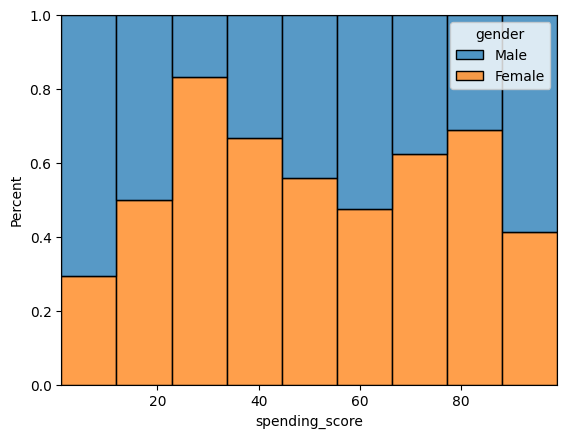

In [86]:
sns.histplot(data=df, x='spending_score', hue='gender', stat='percent', multiple='fill')

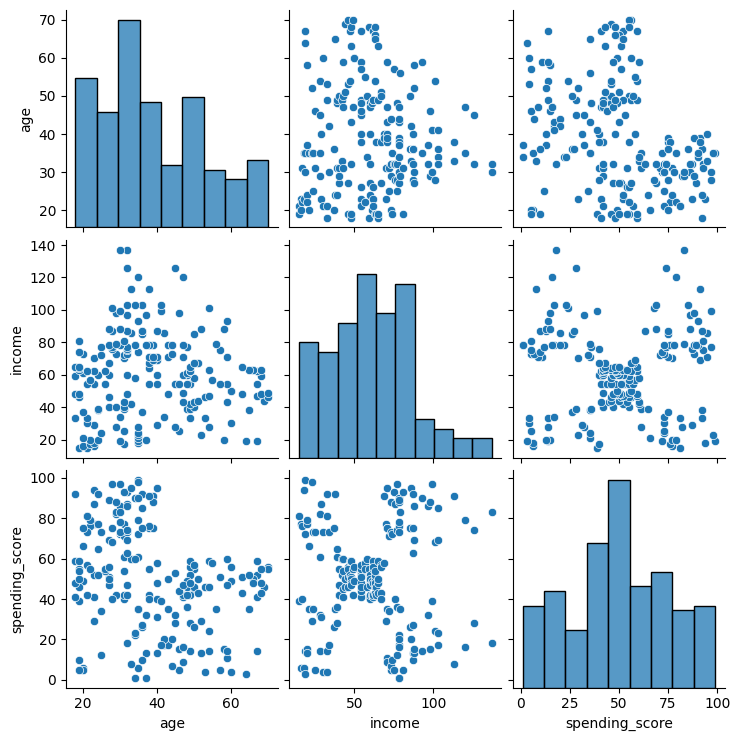

In [87]:
sns.pairplot(df.drop(columns='customer_id'))

We will drop the `customer_id` column, as it’s simply an identifier and isn’t useful for clustering. We’ll also drop the `gender` column since it’s a categorical variable. The standard K-Means algorithm doesn’t handle categorical data well because it relies on calculating Euclidean distances, which aren’t meaningful for categorical variables, even if they’re binary or ordinal encoded.

There are, however, variations of the K-Means algorithm that can work with categorical data:
- **KModes**: Designed specifically for clustering categorical data.
- **KPrototypes**: Suitable for mixed data types (both numerical and categorical).

In [88]:
df.drop(columns=['customer_id', 'gender'], inplace=True)

In [89]:
df

,age,income,spending_score
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40
...,...,...,...
195,35,120,79
196,45,126,28
197,32,126,74
198,32,137,18


Before applying clustering, we need to standardize our features, as they have different ranges. Without standardization, the algorithm would not treat distances along each axis equally, potentially skewing the clustering results.

In [90]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)
df_scaled

,age,income,spending_score
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980
...,...,...,...
195,-0.276302,2.268791,1.118061
196,0.441365,2.497807,-0.861839
197,-0.491602,2.497807,0.923953
198,-0.491602,2.917671,-1.250054


### KMeans<a id="kmeansp">

In [91]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)

kmeans.fit(df_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [92]:
df_labeled = df.copy()
df_labeled['label'] = kmeans.labels_

In [93]:
df_labeled.label.value_counts()

label
0    91
1    68
2    41
Name: count, dtype: int64

After fitting the K-Means model, it generates an attribute, `kmeans.labels_`, which contains the cluster label assigned to each row in the dataset.

Once clusters are created, it’s important to interpret and understand the characteristics that define each cluster. This can be done through data visualization techniques, such as pair plots and box plots, to highlight the unique features and patterns within each customer segment.

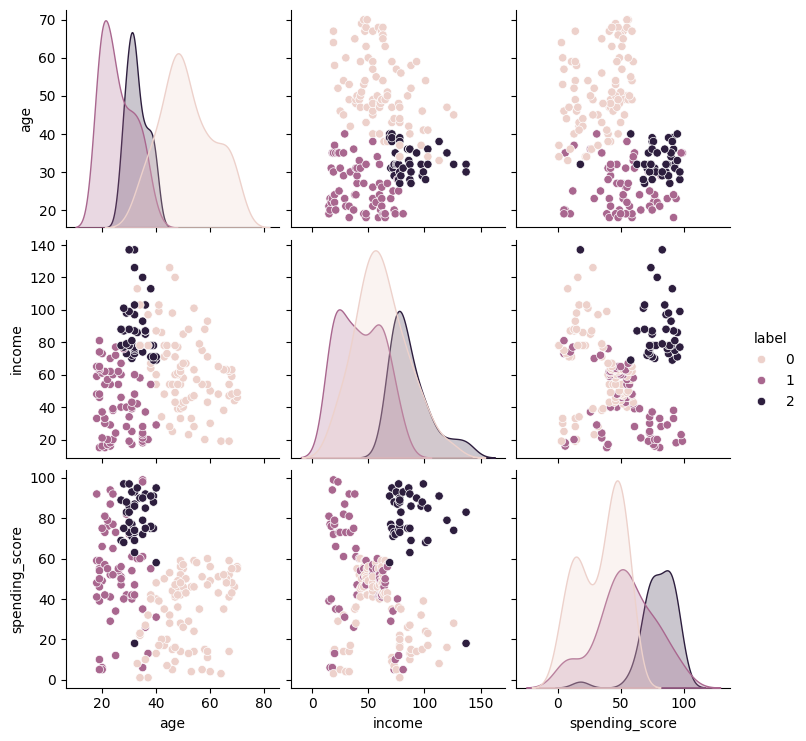

In [94]:
sns.pairplot(data=df_labeled, hue='label')

<Axes: xlabel='label', ylabel='income'>

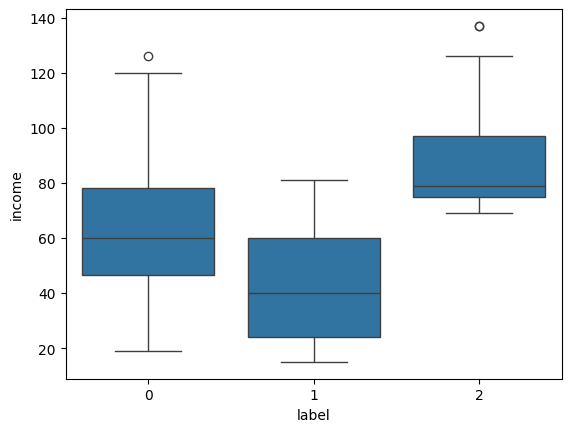

In [95]:
sns.boxplot(data=df_labeled, x='label', y='income')

<Axes: xlabel='label', ylabel='age'>

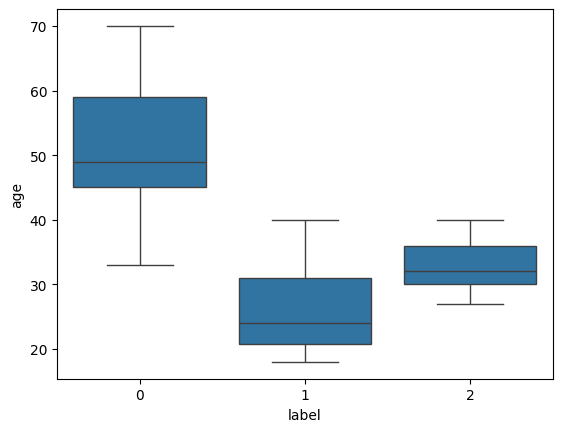

In [96]:
sns.boxplot(data=df_labeled, x='label', y='age')

<Axes: xlabel='label', ylabel='spending_score'>

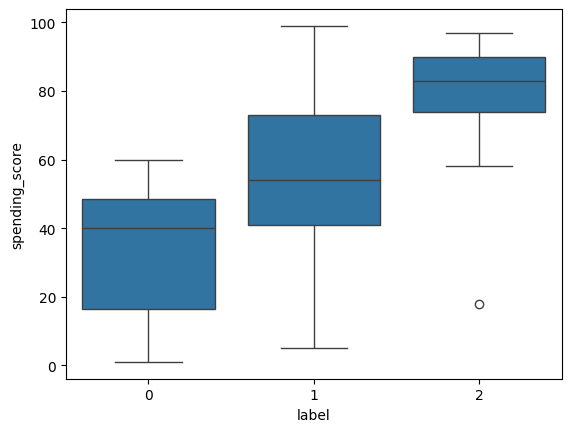

In [97]:
sns.boxplot(data=df_labeled, x='label', y='spending_score')

We can also reduce the dimensionality of our dataset using PCA (Principal Component Analysis) to visualize the clusters in a 2D space. In this reduced dimension, we would expect points within the same cluster to be positioned close to each other, making the cluster structure easier to interpret.

In [98]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled[['age', 'income', 'spending_score']])
pca_df = pd.DataFrame(pca_result, columns=['PCA1', 'PCA2'])
pca_df['label'] = df_labeled['label']

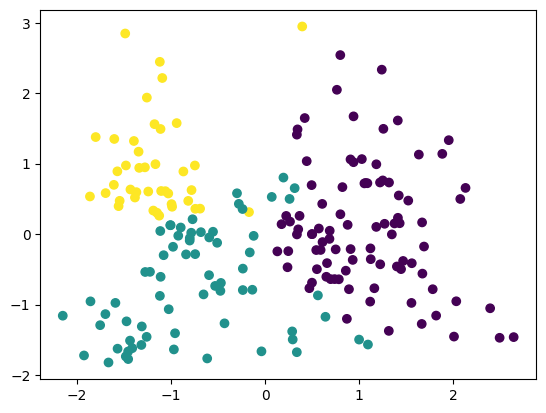

In [99]:
import matplotlib.pyplot as plt

plt.scatter(pca_df.PCA1, pca_df.PCA2, c=pca_df['label'])

For now, we've grouped our data into 3 clusters using K-Means. Next, let’s determine what would be the optimal number of clusters for separating our customers, by applying the Elbow Method.

In [100]:
wcss_list = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k)

    kmeans.fit(df_scaled)

    wcss_list.append(kmeans.inertia_)

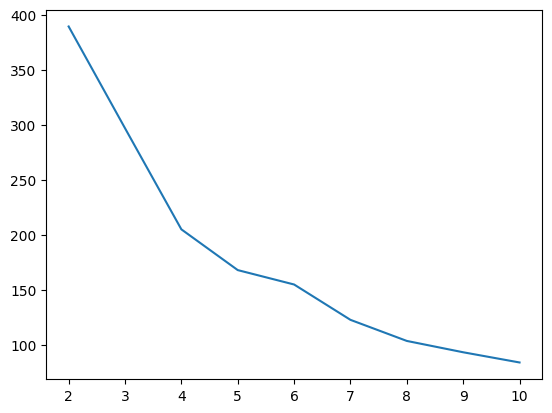

In [101]:
plt.plot(range(2,11), wcss_list)

Based on the elbow method shown in the plot, it seems that the "elbow" (where the rate of decrease sharply diminishes) is around $K = 4$ or $K = 5$. This point indicates the optimal number of clusters since increasing  $K$ beyond this point yields diminishing returns in reducing the within-cluster sum of squares (or inertia).

In [102]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5)

kmeans.fit(df_scaled)

df_labeled = df.copy()
df_labeled['label'] = kmeans.labels_

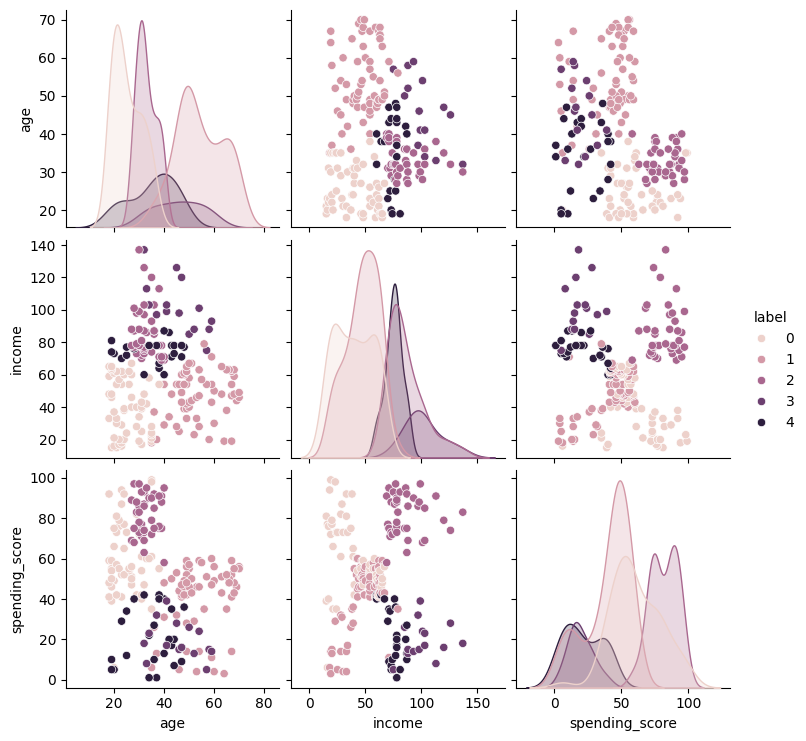

In [103]:
sns.pairplot(data=df_labeled, hue='label')

In [104]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

def evaluate_percent(X, labels, ch_max):
    mask = labels != -1
    X_valid = X[mask]
    labels_valid = labels[mask]

    sil = silhouette_score(X_valid, labels_valid)
    db = davies_bouldin_score(X_valid, labels_valid)
    ch = calinski_harabasz_score(X_valid, labels_valid)

    sil_p = sil * 100
    db_p = (1 / (1 + db)) * 100
    ch_p = (ch / ch_max) * 100

    final_score = (sil_p + db_p + ch_p) / 3

    print(f"Silhouette: {sil_p:.2f}%")
    print(f"Davies-Bouldin: {db_p:.2f}%")
    print(f"Calinski-Harabasz: {ch_p:.2f}%")
    print(f"FINAL SCORE: {final_score:.2f}%")

    return final_score

We could repeat the procedure we did before to analyze the characteristics which define this clustering.

In [105]:
ch_scores = []

# KMeans
labels_k = KMeans(n_clusters=5, random_state=42).fit_predict(df_scaled)
ch_scores.append(calinski_harabasz_score(df_scaled, labels_k))

# Agglomerative
labels_a = AgglomerativeClustering(n_clusters=5).fit_predict(df_scaled)
ch_scores.append(calinski_harabasz_score(df_scaled, labels_a))

# DBSCAN (atenție la -1 = noise)
labels_d = DBSCAN(eps=0.6, min_samples=6).fit_predict(df_scaled)

mask = labels_d != -1
if len(set(labels_d[mask])) > 1: 
    ch_scores.append(calinski_harabasz_score(df_scaled[mask], labels_d[mask]))

In [114]:
ch_max = max(ch_scores)

In [107]:
# KMeans
kmeans = KMeans(n_clusters=5)
labels_k = kmeans.fit_predict(df_scaled)

print("KMeans")
score_k = evaluate_percent(df_scaled, labels_k, ch_max)

KMeans
Silhouette: 35.26%
Davies-Bouldin: 50.83%
Calinski-Harabasz: 82.41%
FINAL SCORE: 56.17%


### Agglomerative Clustering<a id="agglomp">

In [108]:
from sklearn.cluster import AgglomerativeClustering

agglom = AgglomerativeClustering(n_clusters=5)

agglom.fit(df_scaled)


df_labeled = df.copy()
df_labeled['label'] = agglom.labels_

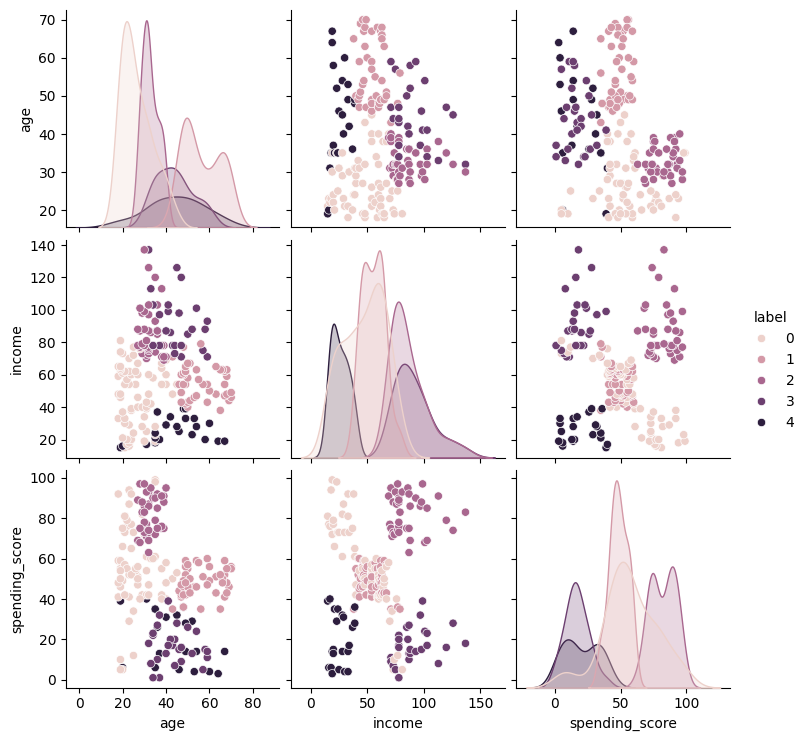

In [109]:
sns.pairplot(data=df_labeled, hue='label')

Scikit-Learn doesn’t provide a straightforward way to visualize dendrograms created during agglomerative clustering. However, we can use SciPy to generate a dendrogram with ease:

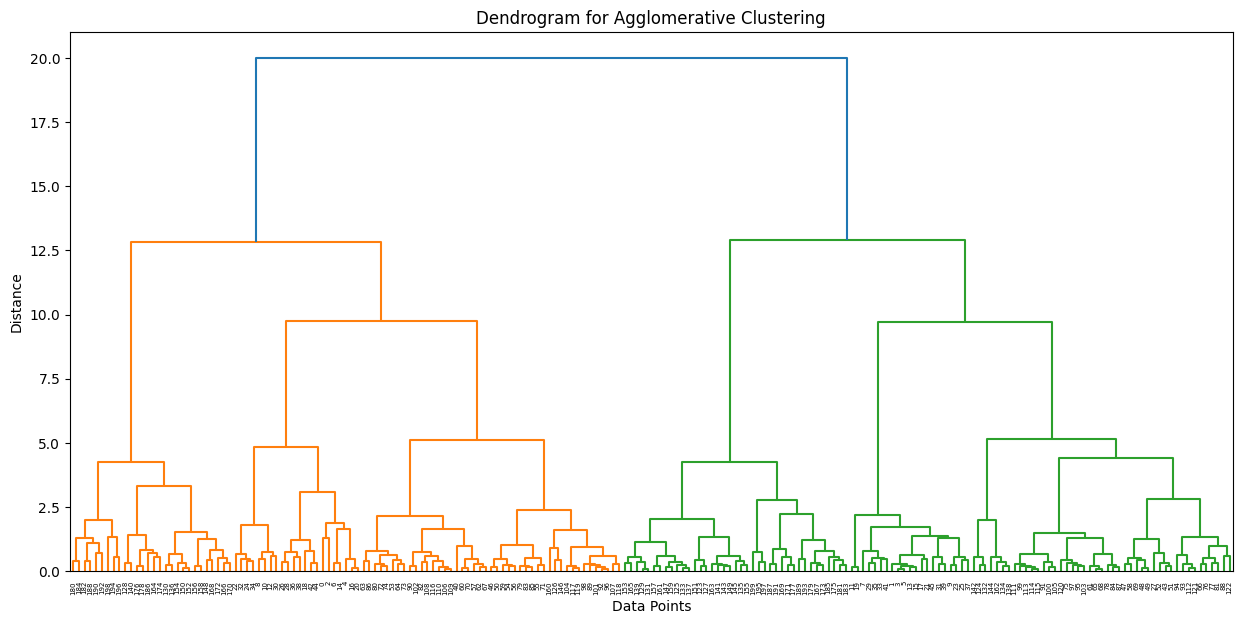

In [110]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Generate the linkage matrix using the Ward linkage method
linkage_matrix = linkage(df_scaled, method='ward')

# Plot the dendrogram
plt.figure(figsize=(15, 7))
dendrogram(linkage_matrix)
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.title('Dendrogram for Agglomerative Clustering')
plt.show()

Let's check some customers which are very similar according to Dendrogram (distance between them is small). They should have similar features. We can select them based on index:

In [111]:
df.iloc[[106, 109]]

,age,income,spending_score
106,66,63,50
109,66,63,48


In [112]:
df.iloc[[150, 152]]

,age,income,spending_score
150,43,78,17
152,44,78,20


In [115]:
# Agglomerative
from sklearn.cluster import AgglomerativeClustering
agg = AgglomerativeClustering(n_clusters=5)
labels_a = agg.fit_predict(df_scaled)

print("\nAgglomerative")
score_a = evaluate_percent(df_scaled, labels_a, ch_max)



Agglomerative
Silhouette: 39.00%
Davies-Bouldin: 52.18%
Calinski-Harabasz: 87.37%
FINAL SCORE: 59.52%


### DBSCAN<a id="dbscanp">

Before applying DBSCAN, we need to determine the optimal values for the parameters `eps` and `min_samples`. A common guideline is to set `min_samples` to twice the number of features in our dataset. For selecting `eps`, we can follow the approach outlined in [this article](https://www.sefidian.com/2022/12/18/how-to-determine-epsilon-and-minpts-parameters-of-dbscan-clustering/).

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
neighbors = NearestNeighbors(n_neighbors=6)
neighbors.fit(df_scaled)
distances, indices = neighbors.kneighbors(df_scaled)

In [ ]:
mean_distances = distances.mean(axis=1)
#sorted descendingly
sorted_vals = np.sort(mean_distances)[::-1]

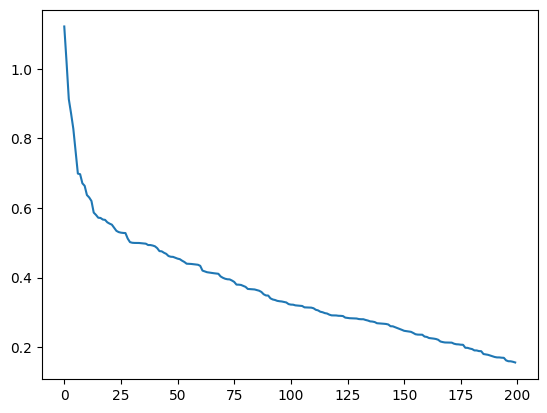

In [ ]:
plt.plot(sorted_vals)

Based on the plot, we can choose eps at around 0.6

In [ ]:
from sklearn.cluster import DBSCAN


db = DBSCAN(eps=0.6, min_samples=6)

db.fit(df_scaled)


df_labeled = df.copy()
df_labeled['label'] = db.labels_

In [ ]:
df_labeled

,age,income,spending_score,label
0,19,15,39,-1
1,21,15,81,0
2,20,16,6,-1
3,23,16,77,0
4,31,17,40,-1
...,...,...,...,...
195,35,120,79,-1
196,45,126,28,-1
197,32,126,74,-1
198,32,137,18,-1


In [ ]:
df_labeled.label.value_counts()

label
 0    105
-1     34
 3     34
 4     18
 1      5
 2      4
Name: count, dtype: int64

We can see that the data has been divided into 5 clusters. Points labeled `-1` represent noise (or outliers) that are not within the vicinity of any core points, meaning they don’t belong to any cluster.

We can apply next the same visualization techniques as before to determine the characteristics of customers which define each distinct cluster.

In [ ]:
# DBSCAN
from sklearn.cluster import DBSCAN
db = DBSCAN(eps=0.6, min_samples=6)
labels_d = db.fit_predict(df_scaled)

print("\nDBSCAN")
score_d = evaluate_percent(df_scaled, labels_d, ch_max)



DBSCAN
Silhouette: 0.0762
Davies-Bouldin: 2.1499
Calinski-Harabasz: 20.0939


### EM (Expectation-Maximization / Gaussian Mixture Models),

In [ ]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=5, random_state=42)

gmm.fit(df_scaled)

labels_gmm = gmm.predict(df_scaled)

In [ ]:
df_labeled = df.copy()
df_labeled['label'] = labels_gmm

df_labeled['label'].value_counts()

label
0    74
1    39
3    37
4    31
2    19
Name: count, dtype: int64

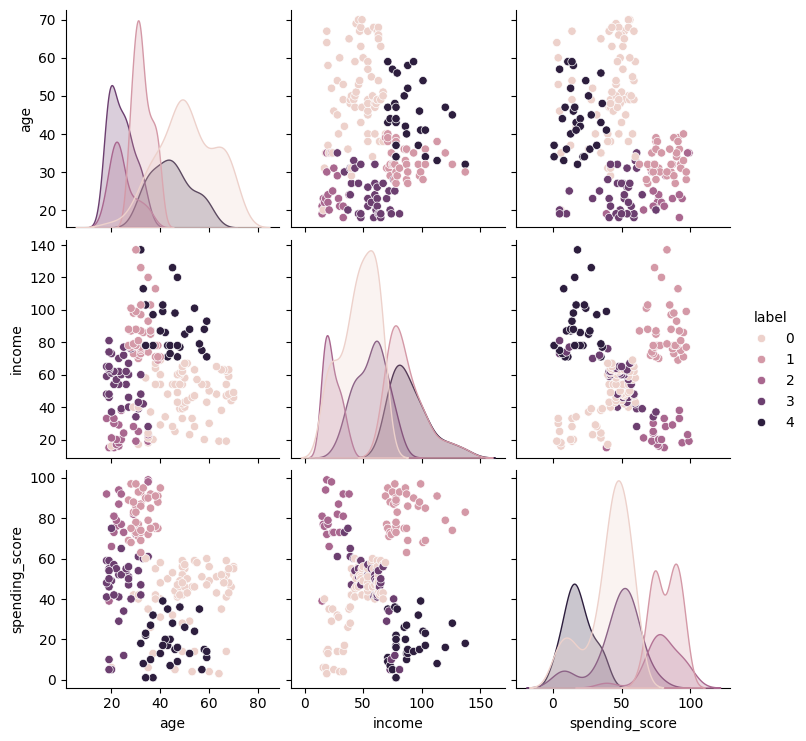

In [ ]:
import seaborn as sns

sns.pairplot(df_labeled, hue='label')

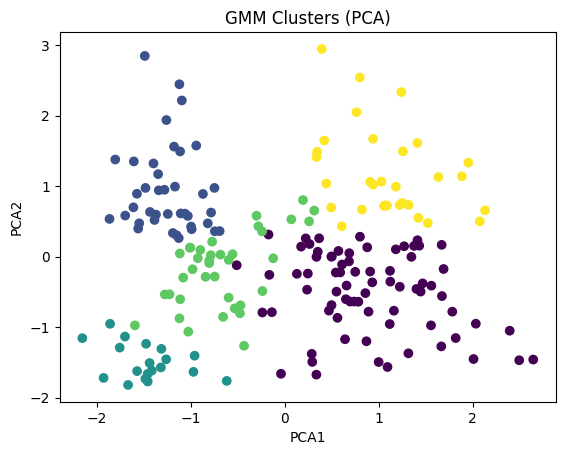

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled)

plt.scatter(pca_result[:,0], pca_result[:,1], c=labels_gmm)
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.title("GMM Clusters (PCA)")
plt.show()

In [ ]:
score_gmm = evaluate_percent(df_scaled, labels_gmm, ch_max)

Silhouette: 68.82%
Davies-Bouldin: 52.91%
Calinski-Harabasz: 83.95%
FINAL SCORE: 68.56%


In [ ]:
df_labeled.groupby('label').mean()

,age,income,spending_score
label,,,
0,50.851351,46.229730,40.635135
1,32.692308,86.538462,82.128205
2,24.526316,23.315789,79.526316
3,24.054054,56.486486,47.189189
4,44.387097,89.774194,18.483871
